## 2-9_Using_Gaussian_processes_for_regression

In [12]:
## 1. Load the California Housing dataset and create a random training set.

from sklearn.datasets import fetch_california_housing
import numpy as np

california = fetch_california_housing()

california_X = california.data[:1000]
california_y = california.target[:1000]

train_set = np.random.choice(
    [True, False],
    len(california_y),
    p=[.75, .25]
)

In [19]:
## 2. Standardize the California Housing features.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

california_X = scaler.fit_transform(california_X)

In [20]:
## 3. Create a Gaussian Process Regressor with the default settings.

from sklearn.gaussian_process import GaussianProcessRegressor

gpr = GaussianProcessRegressor()

gpr

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",None
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [21]:
## 4. Create a kernel by combining a ConstantKernel and an RBF kernel.

from sklearn.gaussian_process.kernels import RBF, ConstantKernel as CK

mixed_kernel = kernel = CK(
    1.0,
    (1e-4, 1e4)
) * RBF(
    10,
    (1e-4, 1e6)
)

In [22]:
## 5. Create a Gaussian Process Regressor using the custom kernel.

gpr = GaussianProcessRegressor(
    alpha=5,
    n_restarts_optimizer=20,
    kernel=mixed_kernel
)

In [23]:
## 6. Fit the Gaussian Process Regressor and predict the test data.

gpr.fit(
    california_X[train_set],
    california_y[train_set]
)

test_preds = gpr.predict(
    california_X[~train_set]
)

Text(0.5, 1.0, 'Histogram of Residuals')

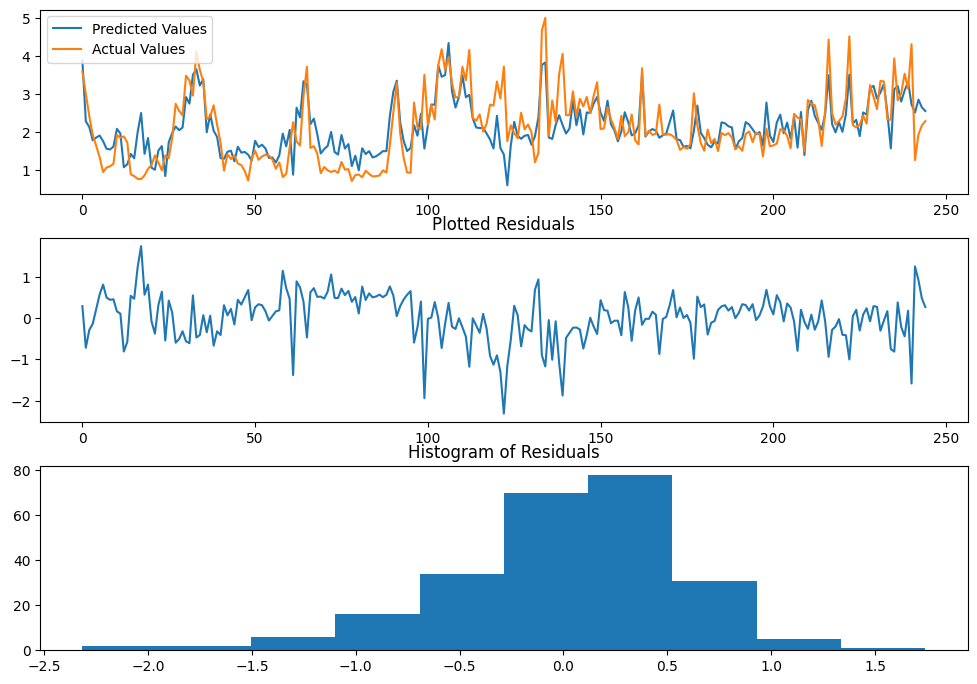

In [24]:
## 7. Plot predicted values, residuals, and the residual distribution.

from sklearn.model_selection import cross_val_predict
 
from matplotlib import pyplot as plt
%matplotlib inline
 
f, ax = plt.subplots(figsize=(10, 7), nrows=3)
f.tight_layout()
 
ax[0].plot(range(len(test_preds)), test_preds, label='Predicted Values');
ax[0].plot(range(len(test_preds)), california_y[~train_set], label='Actual Values');
ax[0].legend(loc='best')
 
ax[1].plot(range(len(test_preds)), test_preds - california_y[~train_set]);
ax[1].set_title("Plotted Residuals")
ax[2].hist(test_preds - california_y[~train_set]);
ax[2].set_title("Histogram of Residuals")

In [25]:
## 8. Evaluate the Gaussian Process Regressor with alpha=5 using cross-validation.

from sklearn.model_selection import cross_val_score

 
gpr5 = GaussianProcessRegressor(
    alpha=5,
    n_restarts_optimizer=20,
    kernel=mixed_kernel
)

 
scores_5 = (
    cross_val_score(
        gpr5,
        california_X[train_set],
        california_y[train_set],
        cv=4,
        scoring='neg_mean_absolute_error'
    )
)

In [26]:
## 9. Display a summary of the cross-validation scores.

def score_mini_report(scores_list):
    print("List of scores: ", scores_list)
    print("Mean of scores: ", scores_list.mean())
    print("Std of scores: ", scores_list.std())


score_mini_report(scores_5)

List of scores:  [-0.39072046 -0.57049313 -0.29354474 -0.40271436]
Mean of scores:  -0.4143681749117276
Std of scores:  0.0995845493721388


In [27]:
## 10. Evaluate the Gaussian Process Regressor with alpha=7 using cross-validation.

gpr7 = GaussianProcessRegressor(
    alpha=7,
    n_restarts_optimizer=20,
    kernel=mixed_kernel
)


scores_7 = (
    cross_val_score(
        gpr7,
        california_X[train_set],
        california_y[train_set],
        cv=4,
        scoring='neg_mean_absolute_error'
    )
)

score_mini_report(scores_7)

List of scores:  [-0.41070591 -0.5971798  -0.30090748 -0.3952978 ]
Mean of scores:  -0.42602274911671295
Std of scores:  0.1073862122365639


In [28]:
## 11. Evaluate the Gaussian Process Regressor with target normalization.

from sklearn.model_selection import cross_val_score


gpr7n = GaussianProcessRegressor(
    alpha=7,
    n_restarts_optimizer=20,
    kernel=mixed_kernel,
    normalize_y=True
)


scores_7n = (
    cross_val_score(
        gpr7n,
        california_X[train_set],
        california_y[train_set],
        cv=4,
        scoring='neg_mean_absolute_error'
    )
)

score_mini_report(scores_7n)

List of scores:  [-0.37864939 -0.53934004 -0.29013447 -0.35101372]
Mean of scores:  -0.38978440546162063
Std of scores:  0.09209255127430568


In [29]:
## 12. Fit the normalized Gaussian Process Regressor.

gpr7n.fit(
    california_X[train_set],
    california_y[train_set]
)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(length_scale=10)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",7
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossary

In [30]:
## 13. Predict the test data using the fitted Gaussian Process Regressor.

test_preds = gpr7n.predict(
    california_X[~train_set]
)

Text(0.5, 1.0, 'Histogram of Residuals')

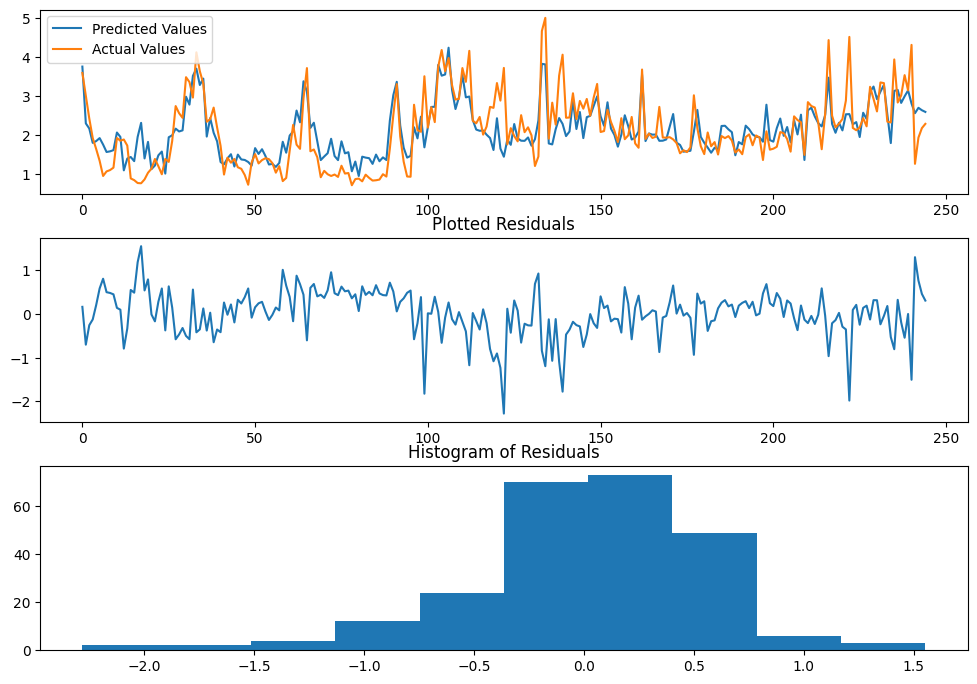

In [34]:
## 14. Plot predicted values, residuals, and the residual distribution.

f, ax = plt.subplots(figsize=(10, 7), nrows=3)
f.tight_layout()

ax[0].plot(range(len(test_preds)), test_preds, label='Predicted Values');
ax[0].plot(range(len(test_preds)), california_y[~train_set], label='Actual Values');
ax[0].legend(loc='best')

ax[1].plot(range(len(test_preds)), test_preds - california_y[~train_set]);
ax[1].set_title("Plotted Residuals")

ax[2].hist(test_preds - california_y[~train_set]);
ax[2].set_title("Histogram of Residuals")

In [36]:
## 15. Create a Gaussian Process Regressor with sample-dependent alpha values.

gpr_new = GaussianProcessRegressor(
    alpha=california_y[train_set] / 4,
    n_restarts_optimizer=20,
    kernel=mixed_kernel
)

gpr_new.fit(
    california_X[train_set],
    california_y[train_set]
)

test_preds = gpr_new.predict(
    california_X[~train_set]
)

Text(0.5, 1.0, 'Histogram of Residuals')

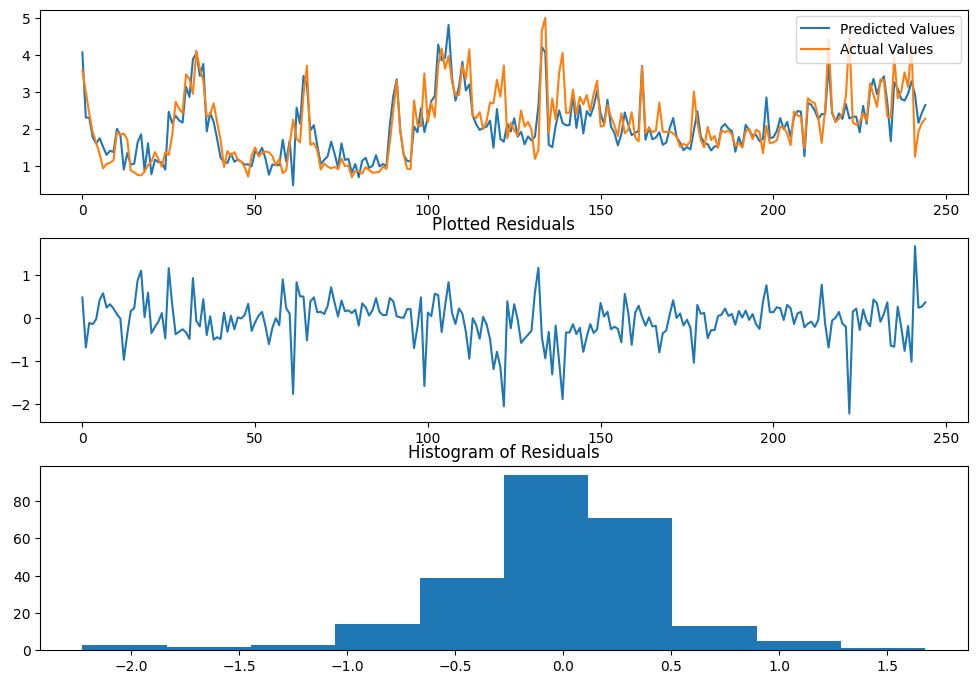

In [37]:
## 16. Plot predicted values, residuals, and the residual distribution for the sample-dependent alpha model.

f, ax = plt.subplots(figsize=(10, 7), nrows=3)
f.tight_layout()

ax[0].plot(
    range(len(test_preds)),
    test_preds,
    label='Predicted Values'
)
ax[0].plot(
    range(len(test_preds)),
    california_y[~train_set],
    label='Actual Values'
)
ax[0].legend(loc='best')

ax[1].plot(
    range(len(test_preds)),
    test_preds - california_y[~train_set]
)
ax[1].set_title("Plotted Residuals")

ax[2].hist(
    test_preds - california_y[~train_set]
)
ax[2].set_title("Histogram of Residuals")

In [38]:
## 17. Predict the test data and obtain the prediction standard deviation.

test_preds, MSE = gpr7n.predict(
    california_X[~train_set],
    return_std=True
)

MSE[:5]

array([0.41227896, 0.19963108, 0.19443159, 0.21821637, 0.17435374])

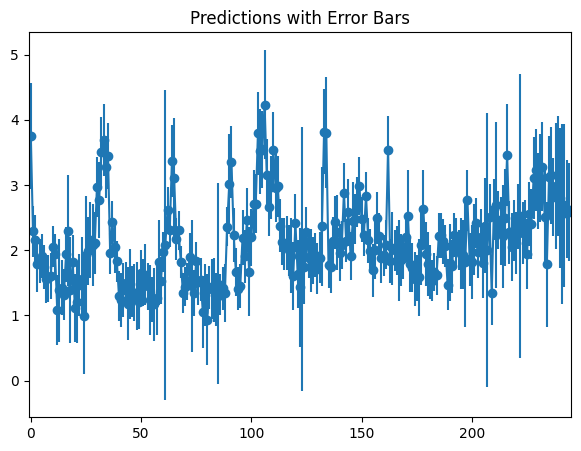

In [39]:
## 18. Plot the predictions with error bars based on the prediction standard deviation.

f, ax = plt.subplots(figsize=(7, 5))

n = MSE.shape[0]
rng = range(n)

ax.scatter(rng, test_preds[:n])
ax.errorbar(
    rng,
    test_preds[:n],
    yerr=1.96 * MSE[:n]
)

ax.set_title("Predictions with Error Bars")
ax.set_xlim((-1, n));

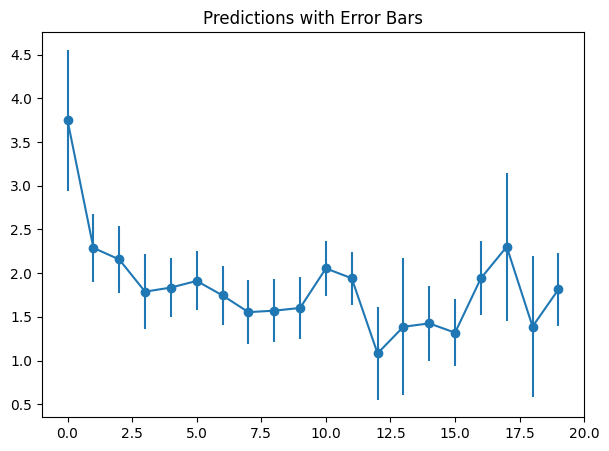

In [ ]:
## 19. Plot the first 20 predictions with error bars based on the prediction standard deviation.

f, ax = plt.subplots(figsize=(7, 5))

n = 20
rng = range(n)

ax.scatter(rng, test_preds[:n])
ax.errorbar(
    rng,
    test_preds[:n],
    yerr=1.96 * MSE[:n]
)

ax.set_title("Predictions with Error Bars")
ax.set_xlim((-1, n));